In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import plotly.express as px
 

colnames=["age", "workclass","fnlwgt", "education", "education-num" , "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"] 
df = pd.read_csv('adult.data', names=colnames, header=None)

def col_filter(x):
    if isinstance(x, str):  # check if x is str
        return x.strip() if x.strip() != '?' else None
    else:
        return x

possible_values = {}
df_filtered = pd.DataFrame()  # empty dataframe to store updated values

for col in colnames:

    
    df_filtered[col] = df[col].apply(col_filter)
    all_attributes = col, df_filtered[col].unique()
    print(all_attributes[0])


    possible_values[col] = all_attributes[1]



age
workclass
fnlwgt
education
education-num
marital-status
occupation
relationship
race
sex
capital-gain
capital-loss
hours-per-week
native-country
income


In [52]:
#  = [1,2,3]
# list2 = []

# for x in list1:
#     list2.append(x**2)list1

In [53]:
# def fn():
#     print("hello")

# my_fn = fn
# my_fn()

# my_fn = lambda x:  x**2
# my_fn(3)

/home/shithi/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


          workclass     income
0       Federal-gov  38.645833
1         Local-gov  29.479216
2      Never-worked   0.000000
3           Private  21.867289
4      Self-emp-inc  55.734767
5  Self-emp-not-inc  28.492719
6         State-gov  27.195686
7       Without-pay   0.000000


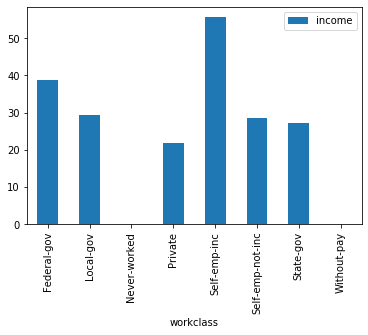

In [54]:
df_scenerio1 = df_filtered[["workclass", "income"]] #taking two columns in pd data frame



df_scenerio1["income"] = df_scenerio1["income"].apply(
    lambda x: 0 if x == "<=50K" else 1
)

# print(df_scenerio1)

df_new = df_scenerio1.groupby(["workclass"]).mean()

df_new["income"] = df_new["income"].apply(
    lambda x: x*100
)

df_new = df_new.reset_index()   #using reset we can ungroup 
print(df_new)

# new_df = df_filtered["income"]
# count = 0
# for item in new_df:
    
#     # print(item)
#     if item == "<=50K":
#         count +=1
#     else:
#         continue

# print(count)


# for item in df_scenerio1:
#     for i in item:
        
 
ax = df_new.plot.bar(x="workclass", y="income", rot=90)

plt.show()

    

In [55]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/pandas-dev/'
    'pandas/main/pandas/tests/io/data/csv/iris.csv'
)

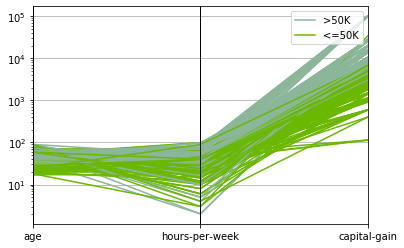

In [61]:
#Scenerio2: native country, hours- per week, capital -loss has any bearing in income.


df_scenerio2 = df_filtered[["race", "capital-gain","hours-per-week", "income" ]]



df_filtered = df_filtered[df_filtered["capital-gain"] != 0] # we are filtering the data where capital gain is zero. other wise our graph doesn't look good.
pd.plotting.parallel_coordinates(df_filtered.sample(1000), 'income', cols=['age', 'hours-per-week', 'capital-gain'])
plt.yscale("log")  
plt.show()

In [57]:
df_filtered[["age", "capital-loss","hours-per-week", "income" ]]

,age,capital-loss,hours-per-week,income
0,39,0,40,<=50K
1,50,0,13,<=50K
2,38,0,40,<=50K
3,53,0,40,<=50K
4,28,0,40,<=50K
...,...,...,...,...
32556,27,0,38,<=50K
32557,40,0,40,>50K
32558,58,0,40,<=50K
32559,22,0,20,<=50K


ValueError: 'c' argument must be a mpl color, a sequence of mpl colors or a sequence of numbers, not ['<=50K' '>50K' '>50K' ... '>50K' '<=50K' '>50K'].

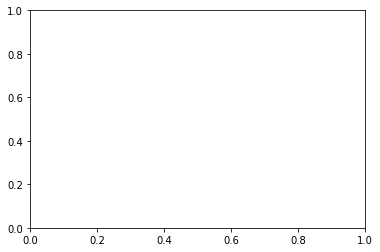

In [67]:

df_filtered.plot.scatter(x='age',y='hours-per-week',c = 'income')

plt.show()
 

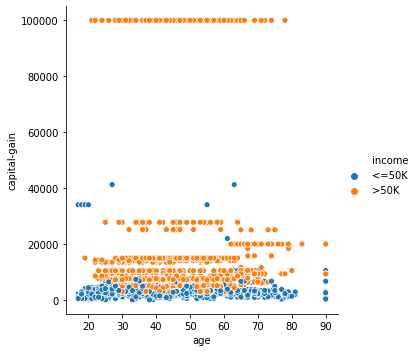

In [71]:
import seaborn as sns
sns.relplot(
    data=df_filtered,
    x='age',y='capital-gain',hue = 'income'   
)

In [73]:
sns.displot(
    df_filtered, x="capital-gain", hue="income", kind="kde"
)

AttributeError: module 'seaborn' has no attribute 'displot'